# Dealing with the Outliers using Z-Score

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes 

In [5]:
diabetics = load_diabetes()
column_names = diabetics.feature_names
df = pd.DataFrame(diabetics.data)
df.columns = column_names

In [6]:
df.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
10,-0.096328,-0.044642,-0.083808,0.008101,-0.103389,-0.090561,-0.013948,-0.076395,-0.062917,-0.034215
100,0.016281,-0.044642,0.017506,-0.022885,0.060349,0.044406,0.030232,-0.002592,0.037236,-0.001078
81,0.012648,0.050680,-0.022373,-0.029770,0.010815,0.028435,-0.021311,0.034309,-0.006081,-0.001078
204,0.110727,0.050680,0.006728,0.028758,-0.027712,-0.007264,-0.047082,0.034309,0.002004,0.077622
426,0.030811,0.050680,-0.034229,0.043666,0.057597,0.068831,-0.032356,0.057557,0.035459,0.085907
375,0.045341,0.050680,-0.002973,0.107944,0.035582,0.022485,0.026550,-0.002592,0.028020,0.019633
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504
166,-0.056370,0.050680,-0.060097,-0.036656,-0.088254,-0.070833,-0.013948,-0.039493,-0.078140,-0.104630
416,-0.027310,-0.044642,0.080019,0.098751,-0.002945,0.018101,-0.017629,0.003312,-0.029526,0.036201
149,-0.049105,0.050680,-0.005128,-0.046985,-0.020832,-0.020416,-0.069172,0.071210,0.061238,-0.038357


In [8]:
mean_value = df['bmi'].mean()
std_dev = df['bmi'].std()
print('Mean: ', mean_value)
print('Std: ', std_dev)

Mean:  -2.2455642172282577e-16
Std:  0.04761904761904761


In [9]:
highest_allowed = mean_value + 3*std_dev
lowest_allowed = mean_value - 3*std_dev

print('Highest Allowed: ', highest_allowed)
print('Lowest Allowed: ', lowest_allowed)

Highest Allowed:  0.1428571428571426
Lowest Allowed:  -0.14285714285714304


C:\Users\jaius\AppData\Local\Temp\ipykernel_20308\4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])
C:\Users\jaius\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='bmi', ylabel='Density'>

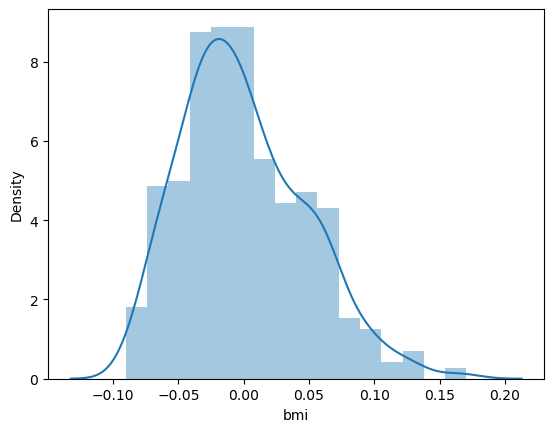

In [13]:
sns.distplot(df['bmi'])

In [20]:
df[(df['bmi'] > highest_allowed) | (df['bmi'] < lowest_allowed)]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
256,-0.049105,-0.044642,0.160855,-0.046985,-0.029088,-0.019790,-0.047082,0.034309,0.028020,0.011349
367,-0.009147,0.050680,0.170555,0.014987,0.030078,0.033759,-0.021311,0.034309,0.033654,0.032059


- ### Using z-score

In [21]:
df['z_score'] = (df['bmi'] - mean_value)/ std_dev

In [22]:
df.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,z_score
47,-0.078165,-0.044642,-0.073030,-0.057313,-0.084126,-0.074277,-0.024993,-0.039493,-0.018114,-0.083920,-1.533636
170,0.023546,0.050680,-0.020218,-0.036656,-0.013953,-0.015092,0.059685,-0.039493,-0.096435,-0.017646,-0.424568
255,0.001751,-0.044642,-0.065486,-0.005670,-0.007073,-0.019476,0.041277,-0.039493,-0.003301,0.007207,-1.375198
253,0.081666,-0.044642,0.033673,0.008101,0.052093,0.056619,-0.017629,0.034309,0.034866,0.069338,0.707135
126,-0.089063,-0.044642,-0.061174,-0.026328,-0.055231,-0.054549,0.041277,-0.076395,-0.093937,-0.054925,-1.284662
143,-0.030942,-0.044642,0.005650,-0.009113,0.019070,0.006828,0.074412,-0.039493,-0.041176,-0.042499,0.118650
339,0.027178,-0.044642,-0.007284,-0.050427,0.075484,0.056619,0.033914,-0.002592,0.043444,0.015491,-0.152959
136,-0.092695,-0.044642,-0.081653,-0.057313,-0.060735,-0.068014,0.048640,-0.076395,-0.066490,-0.021788,-1.714709
383,0.005383,0.050680,-0.028840,-0.009113,-0.031840,-0.028871,0.008142,-0.039493,-0.018114,0.007207,-0.605640
147,-0.056370,-0.044642,0.092953,-0.019442,0.014942,0.023425,-0.028674,0.025453,0.026061,0.040343,1.952008


In [24]:
df[(df['z_score'] > 3) | (df['z_score'] < -3)]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,z_score
256,-0.049105,-0.044642,0.160855,-0.046985,-0.029088,-0.019790,-0.047082,0.034309,0.028020,0.011349,3.377953
367,-0.009147,0.050680,0.170555,0.014987,0.030078,0.033759,-0.021311,0.034309,0.033654,0.032059,3.581660


- ### Capping

In [26]:
lowest_value = mean_value - 3*std_dev
highest_value = mean_value + 3*std_dev

In [28]:
df['bmi'] = np.where(df['bmi'] > highest_value, highest_value, np.where(df['bmi'] < lowest_value, lowest_value, df['bmi']))

In [29]:
df.sample(15)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,z_score
264,0.034443,0.050680,0.028284,-0.033213,-0.045599,-0.009769,-0.050764,-0.002592,-0.059471,-0.021788,0.593965
414,0.081666,0.050680,0.006728,-0.004534,0.109883,0.117056,-0.032356,0.091875,0.054720,0.007207,0.141284
392,-0.041840,0.050680,-0.029918,-0.002228,0.021822,0.036577,0.011824,-0.002592,-0.041176,0.065196,-0.628274
125,-0.005515,0.050680,-0.008362,-0.002228,-0.033216,-0.063630,-0.036038,-0.002592,0.080590,0.007207,-0.175593
227,0.067136,0.050680,-0.029918,0.057437,-0.000193,-0.015719,0.074412,-0.050564,-0.038460,0.007207,-0.628274
338,-0.063635,-0.044642,-0.033151,-0.033213,0.001183,0.024051,-0.024993,-0.002592,-0.022517,-0.059067,-0.696176
148,-0.060003,0.050680,0.015350,-0.019442,0.036958,0.048164,0.019187,-0.002592,-0.030748,-0.001078,0.322356
175,0.067136,-0.044642,-0.038540,-0.026328,-0.031840,-0.026366,0.008142,-0.039493,-0.027129,0.003064,-0.809347
49,-0.041840,0.050680,0.014272,-0.005670,-0.012577,0.006202,-0.072854,0.071210,0.035459,-0.013504,0.299722
23,0.045341,0.050680,0.060618,0.031065,0.028702,-0.047347,-0.054446,0.071210,0.133597,0.135612,1.272986


In [31]:
df[(df['bmi'] > highest_allowed) | (df['bmi'] < lowest_allowed)]

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,z_score


# Outlier Removal Using Inter Quartile Range(IQR)

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [9]:
df = pd.read_csv('scholarship.csv')

In [10]:
df.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\2060931327.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['scholarship_exam_marks'])
C:\Users\jaius\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

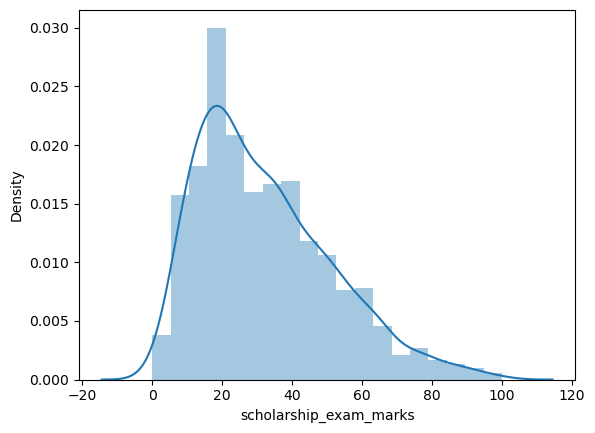

In [14]:
sns.distplot(df['scholarship_exam_marks'])

<Axes: >

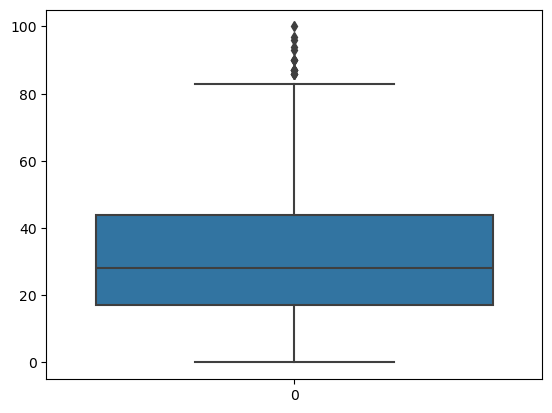

In [15]:
sns.boxplot(df['scholarship_exam_marks'])

In [12]:
Q1 = df['scholarship_exam_marks'].quantile(0.25)
Q3 = df['scholarship_exam_marks'].quantile(0.75)
print(Q1, Q3)

17.0 44.0


In [13]:
IQR = Q3 - Q1
print(IQR)

27.0


In [16]:
min = Q1 - 1.5 * IQR
max = Q3 + 1.5 * IQR
print(min, max)

-23.5 84.5


### Trimming

In [17]:
df[(df['scholarship_exam_marks'] < min) | (df['scholarship_exam_marks'] > max)]

,semester_percentage,scholarship_exam_marks,got_scholarship
9,77.5,94,1
40,66.0,86,1
61,75.1,86,0
134,63.3,93,0
162,78.0,90,0
283,70.9,87,0
290,83.8,87,0
311,69.7,87,1
324,66.4,90,0
630,65.6,96,1


### Capping

In [18]:
df['scholarship_exam_marks'] = np.where(df['scholarship_exam_marks'] < min, min, np.where(df['scholarship_exam_marks'] > 
                                                                                         max, max, df['scholarship_exam_marks'])) 

In [22]:
import matplotlib.pyplot as plt

In [23]:
data = pd.read_csv('scholarship.csv')

C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\3973523881.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['scholarship_exam_marks'])
C:\Users\jaius\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\3973523881.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
sim

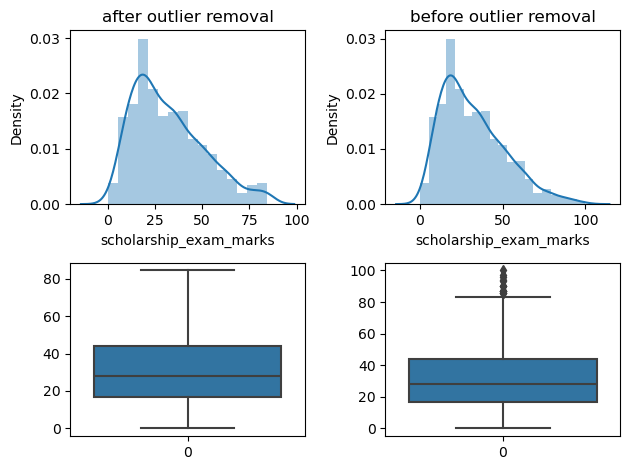

In [26]:
plt.subplot(2,2,1)
plt.title('after outlier removal')
sns.distplot(df['scholarship_exam_marks'])

plt.subplot(2,2,2)
plt.title('before outlier removal')
sns.distplot(data['scholarship_exam_marks'])

plt.subplot(2,2,3)
sns.boxplot(df['scholarship_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(data['scholarship_exam_marks'])

plt.tight_layout()

- ## Outlier Removal Using Percentile

In [27]:
data_2 = pd.read_csv('weight-height.csv')

In [28]:
data_2.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\2962394609.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2['Height'])
C:\Users\jaius\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


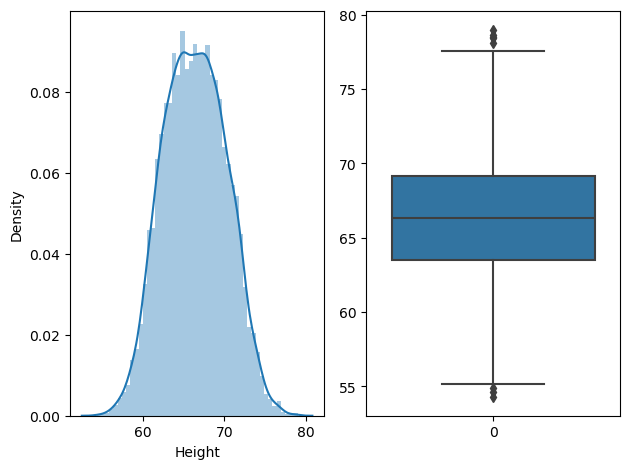

In [36]:

plt.subplot(1,2,1)
sns.distplot(data_2['Height'])

plt.subplot(1,2,2)
sns.boxplot(data_2['Height'])
plt.tight_layout()

In [37]:
min_per = data_2['Height'].quantile(0.01)
max_per = data_2['Height'].quantile(0.99)

In [38]:
print(min_per, max_per)

58.13441158671655 74.7857900583366


### Trimming

In [42]:
data_2[(data_2['Height'] < min_per) | (data_2['Height'] > max_per)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


`Trimming is a good practice if we have a lesser number of rows as outliers but here number of rows are large hence we use capping`

### Capping

In [43]:
data_2['Height'] = np.where(data_2['Height'] < min_per, min_per, np.where(data_2['Height'] > 
                                                                         max_per, max_per, data_2['Height']))

In [44]:
data_2.sample(10)

,Gender,Height,Weight
6784,Female,59.735685,129.004418
644,Male,61.773522,149.514839
8014,Female,62.715618,127.938016
5427,Female,63.406085,129.372212
4882,Male,66.022306,167.378817
3668,Male,72.346155,213.129673
3027,Male,68.362858,189.203925
8444,Female,62.157304,128.958407
9579,Female,63.843238,129.777710
869,Male,67.697104,187.423896


In [45]:
data_3 = pd.read_csv('weight-height.csv')

C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\10675864.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_2['Height'])
C:\Users\jaius\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jaius\AppData\Local\Temp\ipykernel_17284\10675864.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility

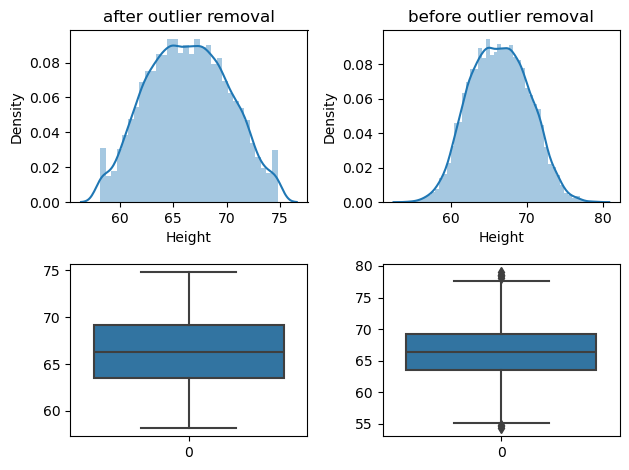

In [46]:
plt.subplot(2,2,1)
plt.title('after outlier removal')
sns.distplot(data_2['Height'])

plt.subplot(2,2,2)
plt.title('before outlier removal')
sns.distplot(data_3['Height'])

plt.subplot(2,2,3)
sns.boxplot(data_2['Height'])

plt.subplot(2,2,4)
sns.boxplot(data_3['Height'])

plt.tight_layout()

- ## Correction of Data-type

In [47]:
data = pd.read_csv('AB_NYC_2019.csv')

In [48]:
data.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
45320,34675072,Bright and beautiful One bedroom apt in Soho.,261559275,Deb,Manhattan,SoHo,40.72646,-74.00213,Entire home/apt,250,2,1,2019-05-14,0.54,1,173
38523,30311099,PRIVATE ROOM IN COZY SCANDINAVIAN / BROOKLYN HOME,220734035,Selma,Brooklyn,Williamsburg,40.70209,-73.94223,Private room,60,3,0,NaN,NaN,1,0
542,197942,"Comfy, Cozy, Brooklyn close to Manhattan",289135,Toni,Brooklyn,Bedford-Stuyvesant,40.68497,-73.95592,Entire home/apt,99,3,207,2019-07-07,2.18,1,304
15310,12267015,UWS BEAUTIFUL 1 Bedroom Available,12759735,Natalie,Manhattan,Upper West Side,40.78400,-73.97148,Entire home/apt,100,1,1,2016-04-24,0.03,1,0
9158,7010681,Gorgeous Garden Apt Steps To Park,36754170,Steve,Brooklyn,Prospect-Lefferts Gardens,40.65703,-73.95964,Entire home/apt,110,1,2,2015-08-10,0.04,1,0
24636,19802994,Entire Loft with Private Bath in Queens,28270349,Jie,Queens,Flushing,40.76589,-73.79449,Entire home/apt,89,1,105,2019-07-07,4.38,2,0
16130,13031826,Modern Brooklyn Lifestyle,18933388,Efrem,Brooklyn,Crown Heights,40.67661,-73.95611,Entire home/apt,225,1,5,2016-07-17,0.13,1,0
13721,10310874,Art Inspired One Bedroom Apt in Bedford Stuyve...,36753915,Ozzy,Brooklyn,Bedford-Stuyvesant,40.69379,-73.94539,Entire home/apt,94,2,37,2018-02-04,0.88,1,0
37559,29799420,Private and cozy room in East Williamsburg.,53103368,Caroline,Brooklyn,Williamsburg,40.70701,-73.94446,Private room,65,2,0,NaN,NaN,1,6
37860,29963575,VAL'S PLACE,225283096,Valentine,Queens,Rosedale,40.65567,-73.73076,Private room,65,1,45,2019-06-16,6.75,1,277


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### convert the host_id into a string

In [53]:
data['host_id'] = data['host_id'].astype(str)

In [54]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  object 
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### convert the last_review to data-time object

In [56]:
data['last_review'] = pd.to_datetime(data['last_review'])

In [57]:
data.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
43787,33874579,Middle town luxury studio close to penn station,210193549,Jiangbin,Manhattan,Chelsea,40.75114,-73.99843,Entire home/apt,150,8,3,2019-06-12,1.05,1,39
34602,27436334,Modern Stay with a Balcony View in the City,109930093,Chris,Manhattan,East Harlem,40.79505,-73.93126,Entire home/apt,199,2,15,2019-06-22,1.40,2,230
1045,435909,Sunny West Village Dream,2165401,Andrew,Manhattan,West Village,40.73775,-74.00344,Entire home/apt,151,88,19,2016-12-24,0.22,1,249
48355,36210670,little Oasis in New York artistic best Bushwick,272342845,Marc,Brooklyn,Bushwick,40.70181,-73.92541,Entire home/apt,120,30,0,NaT,NaN,2,338
45043,34502889,NEW Sunny Light filled 1BR Apartment in Brooklyn!,260413032,David,Brooklyn,Bedford-Stuyvesant,40.69241,-73.95793,Entire home/apt,149,2,3,2019-07-02,3.00,1,268
7210,5276908,SUN FILLED 1BR in ARTSY FORT GREENE,8858347,Rob,Brooklyn,Fort Greene,40.68792,-73.97319,Entire home/apt,120,21,12,2018-08-13,0.22,1,22
40283,31235791,"Williamsburg 1 Bedroom, Spacious and Classy",228224011,Weston & Gabby,Brooklyn,Williamsburg,40.71359,-73.95574,Entire home/apt,251,1,17,2019-06-26,2.91,1,340
507,181972,Gorgeous Entire Manhattan Townhouse,872121,Rosario,Manhattan,Harlem,40.82960,-73.94651,Entire home/apt,199,2,111,2019-06-02,1.17,1,12
7091,5119201,"SpaciousRoom in the heart of New York,Times Sq...",17450152,Tiba,Manhattan,Hell's Kitchen,40.76332,-73.98840,Private room,150,1,38,2019-06-21,0.77,5,307
40982,31877977,Stunning Private Bedroom in UWS 107,238321374,Eyal,Manhattan,Upper West Side,40.79881,-73.95960,Private room,60,30,0,NaT,NaN,32,329


In [59]:
data['last_review'].fillna(data['last_review'].mode()[0], inplace = True)

In [61]:
data.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
10414,7973484,Sunny Apt. on the UES in NYC,17770287,Nina,Manhattan,Upper East Side,40.76769,-73.95236,Entire home/apt,115,30,12,2019-02-08,0.27,14,239
33119,26134096,"LGA cozy apt, Close to Astoria, Manhattan, JFK",156948703,Asad,Queens,East Elmhurst,40.76956,-73.87347,Entire home/apt,99,1,94,2019-07-07,7.32,6,333
6195,4533010,Spacious Manhattan One Bedroom Apt,23503432,Luke,Manhattan,Washington Heights,40.85520,-73.93354,Entire home/apt,80,1,150,2019-06-28,2.68,1,35
11183,8663101,Large room in UWS 92nd near RivPark,45516192,Philip,Manhattan,Upper West Side,40.79360,-73.97442,Private room,100,5,91,2019-06-17,2.07,1,279
44500,34260123,"3BR Apartment in Bushwick, 1 min to Train!",258682005,Terly,Queens,Ridgewood,40.69526,-73.90263,Entire home/apt,210,7,2,2019-05-26,1.13,1,142
4336,2908417,Huge Room in Brooklyn Loft,10593364,Jeffrey,Brooklyn,Bedford-Stuyvesant,40.69924,-73.94057,Private room,42,7,6,2017-09-10,0.10,1,0
39164,30554915,Clean & Spacious Private Bedroom 2 min. to Subway,24594462,Fatima,Manhattan,East Harlem,40.79617,-73.94600,Private room,95,2,27,2019-06-25,3.91,2,33
1766,796232,"Cozy Apt in Bushwick, Brooklyn!",4194142,Alexandra,Brooklyn,Bushwick,40.70308,-73.92765,Entire home/apt,115,4,12,2018-09-21,0.18,1,0
33170,26182774,Private Bedrm & Bath in Luxury Apt,7918430,Stephen Lionel,Manhattan,Harlem,40.80715,-73.95301,Private room,112,2,31,2019-06-06,2.59,2,340
18566,14661553,Bright and clean room in a quaint neighborhood,515095,Mei,Brooklyn,Carroll Gardens,40.67954,-73.99935,Private room,100,2,93,2019-06-23,2.78,2,74


In [62]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  object        
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu